In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib

# Lab EM6 - GPR Data Collection

Due: Noon 2/21/2025

Objectives:
* Learn to operate the GPR
* Adjust parameters on the GPR to image targets on Kafadar
* Take field notes


# Equipment

There are two controlers that we can use, both from Sensors and Software:

## Controllers:

1. The PulseEkko from sensors and software

    ![Pulse Echo](https://www.sensoft.ca/wp-content/uploads/2018/05/pulseEKKO_Systems.jpg)

   Here is the [user manual](https://www.sensoft.ca/wp-content/uploads/2022/07/pulseEKKO-Manual-2005-00040-10.pdf), note though that this is for a newer version of the Digital Video Logger than the GP department has, but the operation should still be similar.

2. The SPIDAR: [User Manual](https://www.sensoft.ca/wp-content/uploads/2022/01/SPIDAR-Operations-Manual-2018-00022-03.pdf)

   ![SPIDAR Controller 1](https://www.sensoft.ca/wp-content/uploads/2018/05/500N.jpg)

   ![SPIDAR Controller 2](https://www.sensoft.ca/wp-content/uploads/2018/05/500X.jpg)


## Antennas:

Specifically we have access to antennas:
* 50 Mhz
* 100 Mhz
* 200 Mhz
* 250Mhz
* 500Mhz
* 1 Ghz

![Antennas](https://www.sensoft.ca/wp-content/uploads/2018/07/pulse-EKKO-group-of-antennas-e1530820512915.png)


The Spider has been set up for you to use the larger 100 Mhz antenna's, and the PulseEkko is set up to use the higher frequency shielded antennas.

# Survey

Your surveying task for Lab 6 will be to collect GPR data over 4 different targets over Kafadar Commons.
![Kafadar targets](../../notes/em/resources/kafadar.png)

## Tasks
Some targets are better for GPR than others, and some antenna's are better for certain targets. Some options are:
* Tunnel
* Manhole cover
* Clandestine Graves
* Granite Block
* Acheaology wall
* Dipping Slab

You shall split into 4 groups each choosing a target and begin marking out your surveys, using tape measures to orient your line(s).

Experiment with choosing different survey parameters to attempt to image your target. Each instrument can visualize the data on screen for you. You can adjust:
* Number of stacks (how many recordings are measured and averaged at each point)
* Spatial sampling rate
* Total measurement time

Hopefully you will be able to identify your target on the screen! If not don't worry too much, as the top soil of Kafadar is pretty conductive and difficult to penetrate.

> Be sure to take notes on how the instruments are set up, what parameters you use for testing (what worked what didn't), and your best coonfiguration you've found for the target.

## Deliverables:

1) Relevant copy of your field notebooks
2) Describe the effect that the different configurations had on the data you recorded.
3) Plot the data over your target for your "best" configuration.

# Plotting Example

Here we read in the `csv` files and make a simple plot

In [4]:
dat_dir = pathlib.Path("data/lab6/manhole")
file_name = "Line00.csv"
line = pd.read_csv(dat_dir/file_name)

In [5]:
line

,Unnamed: 0,TRACE,1,2,3,4,5,6,7,8,...,291,292,293,294,295,296,297,298,299,300
0,NaN,Position (m),0.0,0.02,0.04,0.06,0.08,0.1,0.12,0.14,...,5.8,5.82,5.84,5.86,5.88,5.9,5.92,5.94,5.96,5.98
1,Point,Time (ns),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,-4.746000000000000441,15.0,10.00,22.00,7.00,4.00,4.0,29.00,29.00,...,15.0,15.00,22.00,22.00,30.00,30.0,-7.00,-7.00,-8.00,9.00
3,2,-4.546000000000000263,0.0,14.00,9.00,7.00,25.00,25.0,30.00,30.00,...,11.0,11.00,0.00,0.00,-4.00,-4.0,14.00,14.00,18.00,0.00
4,3,-4.346000000000000085,36.0,25.00,14.00,-1.00,-10.00,-10.0,-7.00,-7.00,...,55.0,55.00,20.00,20.00,6.00,6.0,30.00,30.00,32.00,12.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,246,44.25400000000000489,48.0,42.00,19.00,22.00,19.00,19.0,16.00,16.00,...,20.0,20.00,33.00,33.00,5.00,5.0,28.00,28.00,23.00,12.00
248,247,44.45400000000000773,22.0,34.00,16.00,36.00,-2.00,-2.0,26.00,26.00,...,18.0,18.00,35.00,35.00,12.00,12.0,29.00,29.00,17.00,11.00
249,248,44.65400000000000347,32.0,26.00,38.00,27.00,12.00,12.0,10.00,10.00,...,3.0,3.00,35.00,35.00,38.00,38.0,23.00,23.00,33.00,24.00
250,249,44.85400000000000631,34.0,15.00,19.00,20.00,17.00,17.0,-5.00,-5.00,...,33.0,33.00,20.00,20.00,65.00,65.0,33.00,33.00,16.00,2.00


In [21]:
times = np.asarray(line['TRACE'][2:], dtype=float)
column_start = 1
column_end = 294
trace_subset = np.asarray(line[[f"{i}" for i in range(column_start, column_end + 1)]])

In [22]:
positions = trace_subset[0]
trace_data = trace_subset[2:]

Text(0, 0.5, 'Time (ns)')

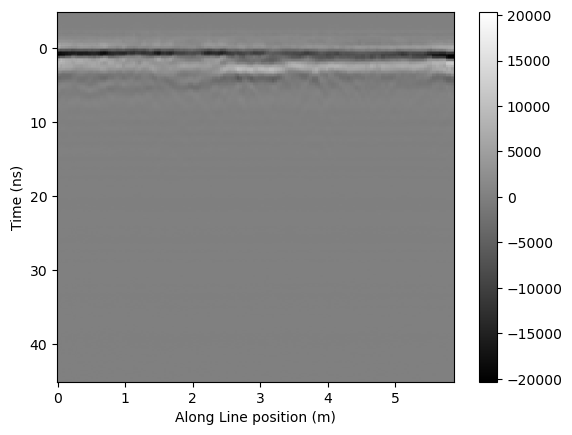

In [31]:

# Grabbing the largest absolute value to make a
# symmetric colormap about 0
abs_max = np.abs(trace_data).max()

# Greyscale is likely the most common colormap used, "seismic" is also common, especially in the seismic arena
cmap = "grey" 

plt.pcolormesh(positions, times, trace_data, cmap='grey', clim=[-abs_max, abs_max])
plt.colorbar()
plt.gca().invert_yaxis()
plt.xlabel('Along Line position (m)')
plt.ylabel('Time (ns)')